# Insurance Fraud Claims Detection Engine
## Complete Machine Learning Analysis

**Project:** Academic Project — B.Tech (Level 1)
**Dataset:** 1,000 Auto Insurance Claims
**Goal:** Classify insurance claims by fraud risk using machine learning.

---

## 1. Problem Statement

Insurance fraud costs the global industry billions of dollars annually and raises premiums for honest customers. Manually reviewing every single claim is slow and error-prone. A data-driven approach can automatically flag suspicious claims for priority investigation.

## 2. Objectives
- Load and explore the actual insurance claims dataset.
- Identify which features are most relevant to fraud detection.
- Build and compare multiple ML classifiers.
- Select the best model using fraud-appropriate metrics (Recall, F1, ROC-AUC).
- Save the final model for integration with the Flask web application.

## 3. Dataset Overview
| Attribute | Detail |
|---|---|
| **Source** | Auto Insurance Claims (Synthetic/Historical) |
| **Total Records** | 1,000 |
| **Total Columns** | 40 |
| **Target Variable** | `fraud_reported` (Y = Fraud, N = Not Fraud) |
| **Missing Values** | Yes — encoded as `?` in several categorical columns |

## 4. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
print("All libraries imported successfully.")

All libraries imported successfully.


## 5. Load Dataset

In [ ]:
DATA_PATH = os.path.join('..', 'data', 'raw', 'insurance_claims.csv')
df_raw = pd.read_csv(DATA_PATH)
print(f"Dataset loaded successfully!")
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")

Dataset loaded successfully!
Shape: 1,000 rows x 40 columns


## 6. Initial Data Inspection

### 6.1 Dataset Shape

In [ ]:
print(f'Rows: {df_raw.shape[0]}  |  Columns: {df_raw.shape[1]}')

Rows: 1000  |  Columns: 40


### 6.2 First 5 Rows

In [ ]:
df_raw.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,?,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,?,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


### 6.3 Data Types

In [ ]:
df_raw.dtypes.to_frame('dtype')

,dtype
months_as_customer,int64
age,int64
policy_number,int64
policy_bind_date,str
policy_state,str
policy_csl,str
policy_deductable,int64
policy_annual_premium,float64
umbrella_limit,int64
insured_zip,int64


### 6.4 Missing Values

> The dataset encodes missing values as `'?'` strings. We first replace them with `NaN` to use pandas' standard missing-value tools.

In [ ]:
# Replace '?' with NaN
df = df_raw.copy()
df.replace('?', np.nan, inplace=True)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = (pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
             .query('`Missing Count` > 0')
             .sort_values('Missing Count', ascending=False))
print("Columns with missing values:")
print(miss_df.to_string())

Columns with missing values:
                         Missing Count  Missing %
_c39                              1000      100.0
property_damage                    360       36.0
police_report_available            343       34.3
collision_type                     178       17.8
authorities_contacted               91        9.1


### 6.5 Duplicate Records

In [ ]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}  ({'No duplicates found.' if dupes == 0 else 'Duplicates present!'})") 

Duplicate rows: 0  (No duplicates found.)


## 7. Exploratory Data Analysis (EDA)

### 7.1 Fraud Distribution

**What it shows:** The proportion of fraudulent vs non-fraudulent claims.

**Why it matters:** Reveals class imbalance — a key factor in model selection. If the dataset were heavily imbalanced, accuracy alone would be misleading.

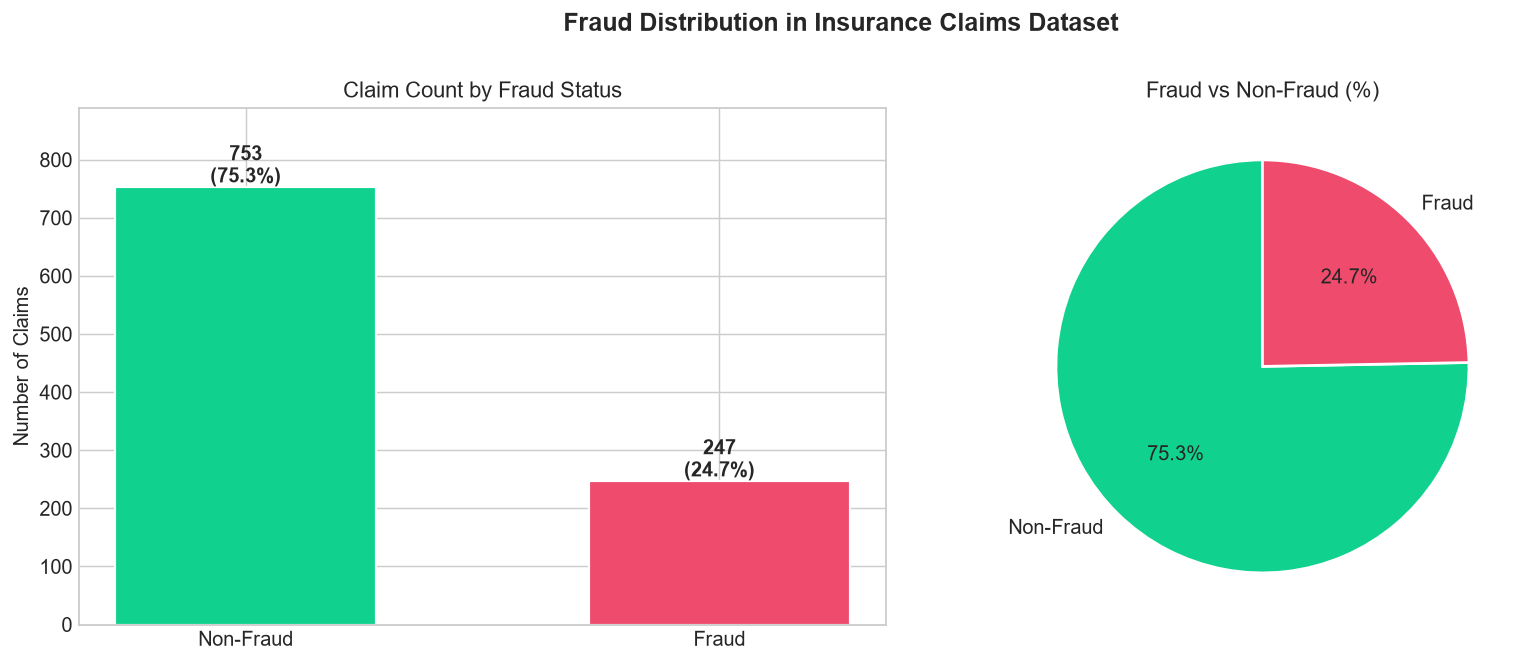

Total claims: 1000  |  Fraud: 247 (24.7%)  |  Non-Fraud: 753 (75.3%)


In [ ]:
counts = df['fraud_reported'].value_counts()
labels = {'N': 'Non-Fraud', 'Y': 'Fraud'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Fraud Distribution in Insurance Claims Dataset', fontsize=14, fontweight='bold', y=1.01)

# Bar chart
colors = ['#10d18e', '#ef4b6c']
bars = axes[0].bar([labels[k] for k in counts.index], counts.values,
                    color=colors, edgecolor='white', linewidth=1.2, width=0.55)
axes[0].set_title('Claim Count by Fraud Status', fontsize=12)
axes[0].set_ylabel('Number of Claims', fontsize=11)
axes[0].set_xlabel('')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 8,
                 f'{val}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, counts.max() * 1.18)
axes[0].tick_params(labelsize=11)

# Pie chart
axes[1].pie(counts.values, labels=[labels[k] for k in counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
            textprops={'fontsize': 11})
axes[1].set_title('Fraud vs Non-Fraud (%)', fontsize=12)

plt.tight_layout()
plt.show()
print(f"Total claims: {len(df)}  |  Fraud: {counts.get('Y',0)} ({counts.get('Y',0)/len(df)*100:.1f}%)  |  Non-Fraud: {counts.get('N',0)} ({counts.get('N',0)/len(df)*100:.1f}%)")

### 7.2 Total Claim Amount Distribution

**What it shows:** How total claimed amounts are distributed, split by fraud label.

**Insight:** If fraudulent claims cluster at higher amounts, `total_claim_amount` will be a strong predictive feature.

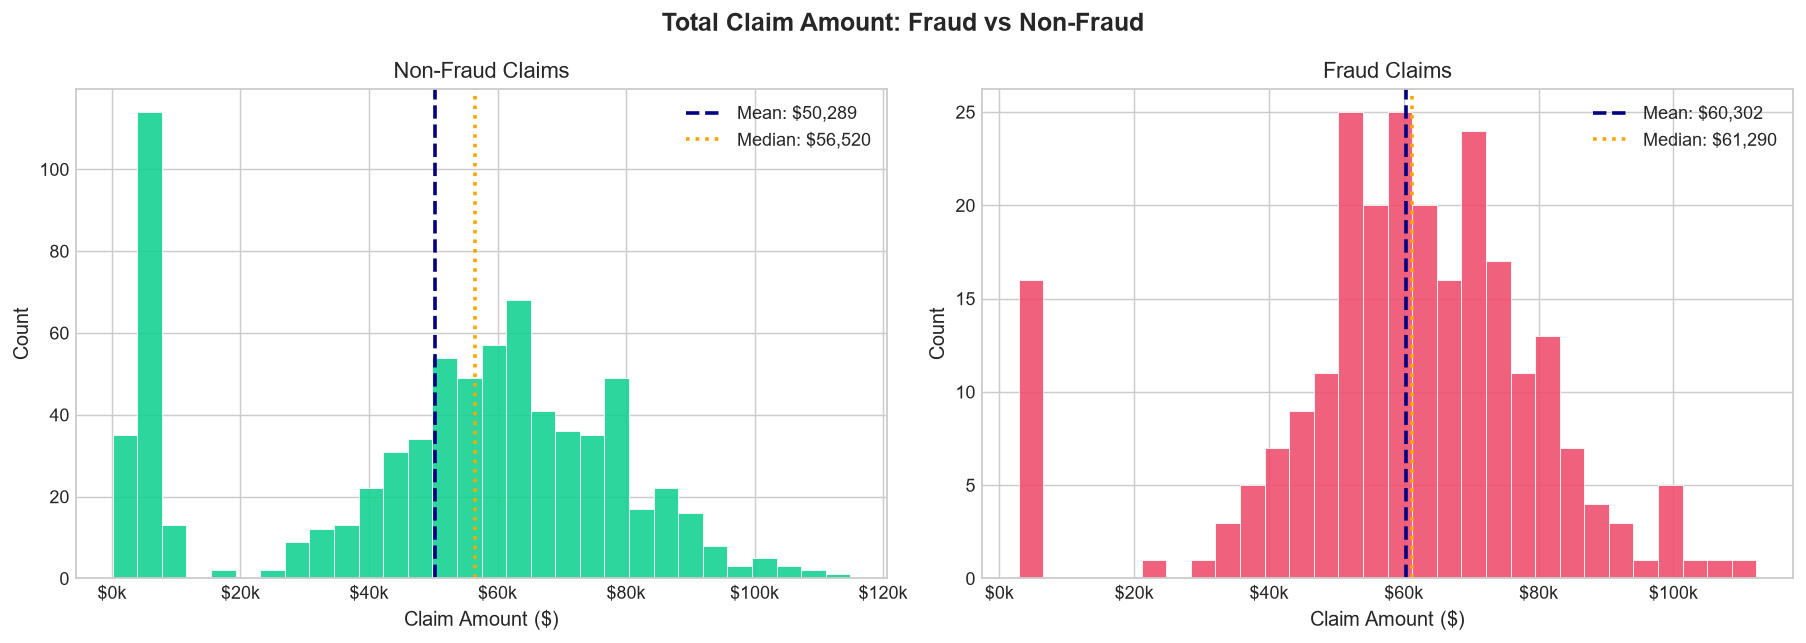

Average claim — Fraud: $60,302  |  Non-Fraud: $50,289


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Total Claim Amount: Fraud vs Non-Fraud', fontsize=14, fontweight='bold')

for ax, (group, label, color) in zip(axes, [('N','Non-Fraud','#10d18e'), ('Y','Fraud','#ef4b6c')]):
    data = df[df['fraud_reported'] == group]['total_claim_amount'].dropna()
    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.88, linewidth=0.5)
    ax.axvline(data.mean(), color='navy', linestyle='--', linewidth=2,
                label=f'Mean: ${data.mean():,.0f}')
    ax.axvline(data.median(), color='orange', linestyle=':', linewidth=2,
                label=f'Median: ${data.median():,.0f}')
    ax.set_title(f'{label} Claims', fontsize=12)
    ax.set_xlabel('Claim Amount ($)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

fraud_mean    = df[df['fraud_reported']=='Y']['total_claim_amount'].mean()
nonfraud_mean = df[df['fraud_reported']=='N']['total_claim_amount'].mean()
print(f"Average claim — Fraud: ${fraud_mean:,.0f}  |  Non-Fraud: ${nonfraud_mean:,.0f}")

### 7.3 Incident Severity vs Fraud

**What it shows:** For each severity level, how many claims were fraudulent vs genuine.

**Insight:** Higher-severity incidents (Major Damage / Total Loss) may correlate with higher fraud rates because the financial incentive is greater.

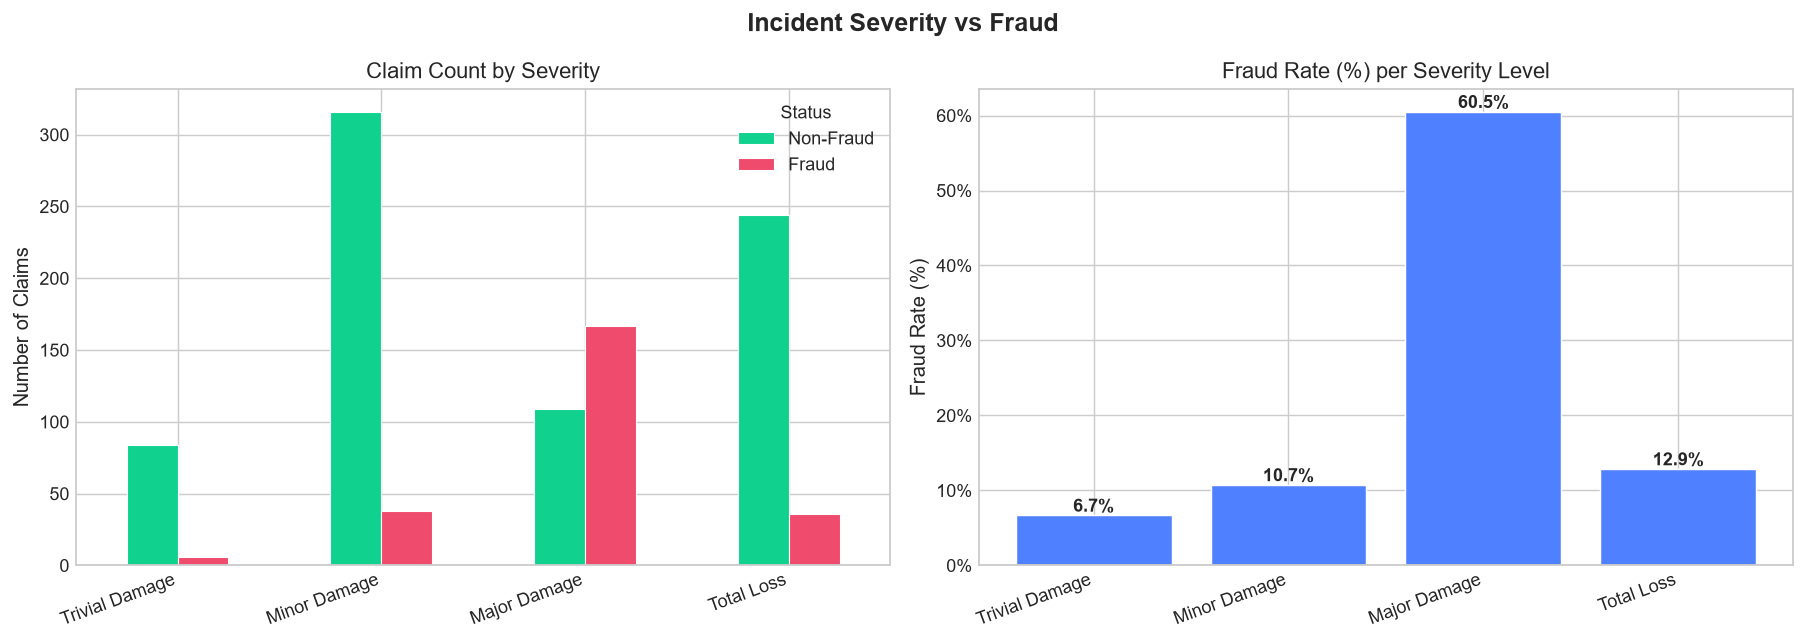

fraud_reported     Non-Fraud  Fraud  Fraud Rate %
incident_severity                                
Trivial Damage            84      6      6.666667
Minor Damage             316     38     10.734463
Major Damage             109    167     60.507246
Total Loss               244     36     12.857143


In [ ]:
order = ['Trivial Damage', 'Minor Damage', 'Major Damage', 'Total Loss']
pivot = (df.groupby(['incident_severity', 'fraud_reported'])
           .size().unstack(fill_value=0)
           .reindex([s for s in order if s in df['incident_severity'].unique()]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Incident Severity vs Fraud', fontsize=14, fontweight='bold')

# Stacked bar
pivot.plot(kind='bar', ax=axes[0], color=['#10d18e','#ef4b6c'],
           edgecolor='white', linewidth=0.6)
axes[0].set_title('Claim Count by Severity', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Claims', fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')
axes[0].legend(['Non-Fraud', 'Fraud'], title='Status')

# Fraud rate per severity
pivot['fraud_rate'] = pivot.get('Y', 0) / pivot.sum(axis=1) * 100
axes[1].bar(pivot.index, pivot['fraud_rate'], color='#4f80ff',
            edgecolor='white', linewidth=0.8)
axes[1].set_title('Fraud Rate (%) per Severity Level', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Fraud Rate (%)', fontsize=11)
axes[1].set_xticklabels(pivot.index, rotation=20, ha='right')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
for i, (idx, row) in enumerate(pivot.iterrows()):
    axes[1].text(i, row['fraud_rate'] + 0.5, f"{row['fraud_rate']:.1f}%",
                 ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
print(pivot[['N','Y','fraud_rate']].rename(columns={'N':'Non-Fraud','Y':'Fraud','fraud_rate':'Fraud Rate %'}).to_string())

### 7.4 Evidence Features vs Fraud

**What it shows:** Claims with 0 witnesses and no police report often have a higher fraud rate. Fraudsters may stage accidents in isolated locations to avoid witnesses and police involvement.

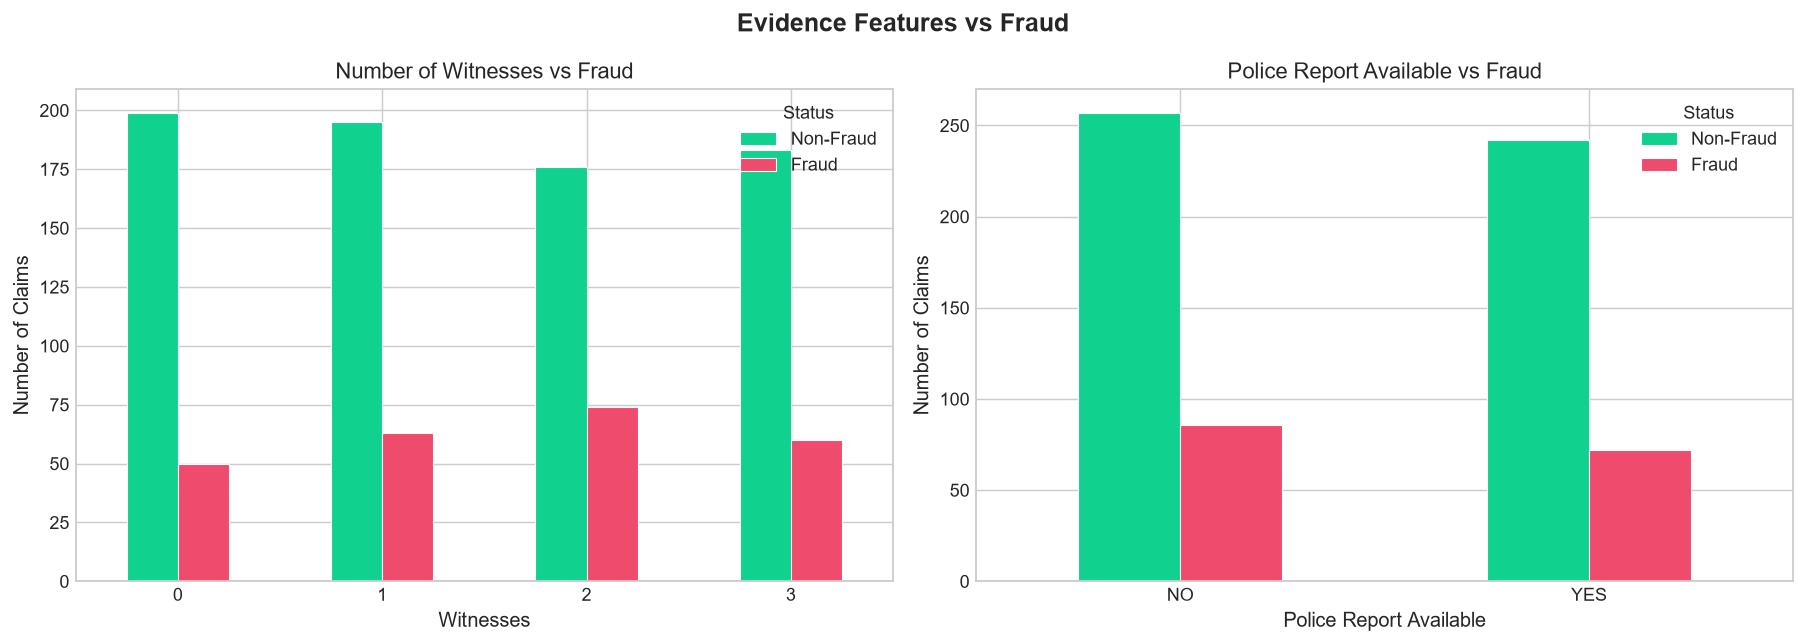

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evidence Features vs Fraud', fontsize=14, fontweight='bold')

for ax, col, title in zip(
    axes,
    ['witnesses', 'police_report_available'],
    ['Number of Witnesses vs Fraud', 'Police Report Available vs Fraud']
):
    sub = (df.groupby([col, 'fraud_reported']).size()
             .unstack(fill_value=0))
    sub.plot(kind='bar', ax=ax, color=['#10d18e','#ef4b6c'],
             edgecolor='white', linewidth=0.6)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(col.replace('_',' ').title(), fontsize=11)
    ax.set_ylabel('Number of Claims', fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(['Non-Fraud', 'Fraud'], title='Status')

plt.tight_layout()
plt.show()

### 7.5 Correlation Matrix — Numerical Features

**What it shows:** Linear relationships between key numerical features.

**Insight:** `injury_claim`, `property_claim`, and `vehicle_claim` are highly correlated with `total_claim_amount` because they are components that sum to it. This is expected — not data leakage.

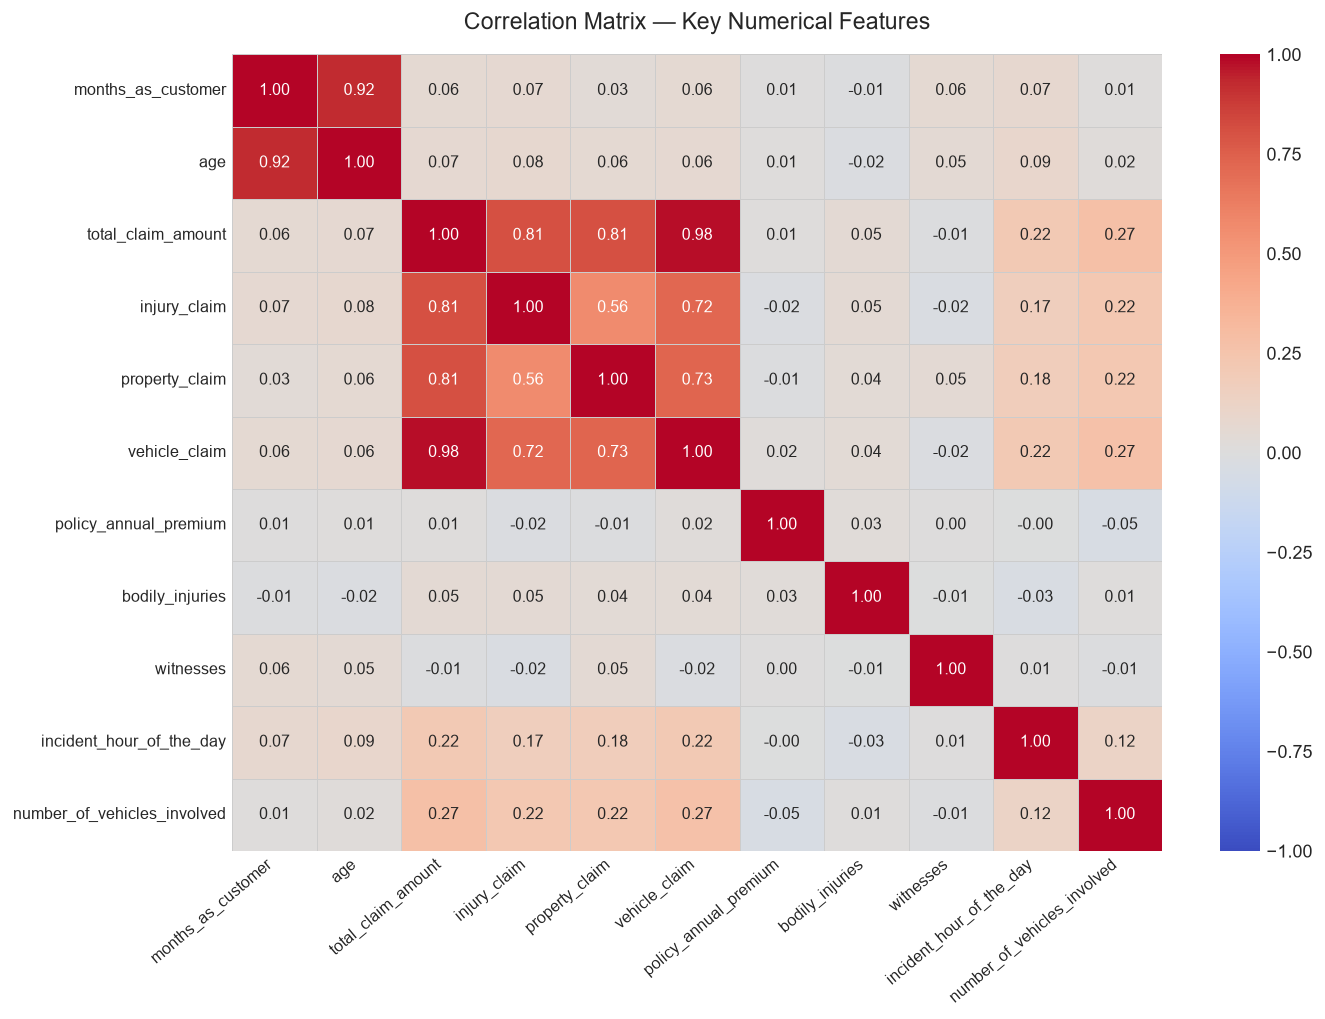

In [ ]:
num_feat = ['months_as_customer', 'age', 'total_claim_amount',
            'injury_claim', 'property_claim', 'vehicle_claim',
            'policy_annual_premium', 'bodily_injuries', 'witnesses',
            'incident_hour_of_the_day', 'number_of_vehicles_involved']

corr = df[num_feat].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # show lower triangle

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.4, linecolor='#ccc',
            annot_kws={'size': 9})
plt.title('Correlation Matrix — Key Numerical Features', fontsize=13, pad=14)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

## 8. Feature Audit

Every column was audited for predictive usefulness, identifier risk, and cardinality before model training.

| Feature | Decision | Reason |
|---|---|---|
| `_c39` | **DROP** | 100% empty — zero values in all 1,000 rows |
| `policy_number` | **DROP** | Unique integer ID per policy — no predictive signal |
| `insured_zip` | **DROP** | 995 unique values — extreme cardinality without geo-encoding |
| `incident_location` | **DROP** | 1,000 unique street addresses — acts as a row identifier |
| `policy_bind_date` | **DROP** | Raw date string — not converted to useful features in this prototype |
| `incident_date` | **DROP** | All incidents are in the same 2-month window — no temporal signal |
| `insured_hobbies` | **DROP** | 20 values; no actuarially defensible link to fraud |
| `insured_occupation` | **DROP** | 14 values; high overlap with other demographic features |
| `insured_education_level` | **DROP** | Low fraud-signal in this dataset |
| `insured_sex` | **DROP** | Legally sensitive; weak signal here |
| `insured_relationship` | **DROP** | Household relationship; low fraud signal |
| `capital-gains` / `capital-loss` | **DROP** | Personal finances unrelated to incident fraud |
| `incident_city` | **DROP** | 7 values; collinear with `incident_state` |
| `incident_state` | **DROP** | 7 values; no strong geographic fraud pattern |
| `auto_model` | **DROP** | 39 unique values; `auto_make` captures brand-level signal |
| `policy_state` | **DROP** | 3 values; collinear with `incident_state` |
| **All others** | **KEEP** | Meaningful claim / incident / policy / vehicle features |

## 9. Feature Selection

In [ ]:
DROP_COLS = [
    '_c39', 'policy_number', 'insured_zip', 'incident_location',
    'policy_bind_date', 'incident_date',
    'insured_hobbies', 'insured_occupation', 'insured_education_level',
    'insured_sex', 'insured_relationship',
    'capital-gains', 'capital-loss',
    'incident_city', 'incident_state', 'auto_model', 'policy_state'
]

df_model = df.drop(columns=DROP_COLS, errors='ignore')
X = df_model.drop('fraud_reported', axis=1)
y = df_model['fraud_reported'].map({'Y': 1, 'N': 0})

num_cols_model = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols_model = X.select_dtypes(include=['object','string']).columns.tolist()

print(f"Total features for model: {X.shape[1]}")
print(f"  Numerical ({len(num_cols_model)}): {num_cols_model}")
print(f"  Categorical ({len(cat_cols_model)}): {cat_cols_model}")
print(f"\nTarget distribution:")
print(y.value_counts().rename({1:'Fraud (1)', 0:'Non-Fraud (0)'}).to_string())

Total features for model: 22
  Numerical (14): ['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year']
  Categorical (8): ['policy_csl', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'property_damage', 'police_report_available', 'auto_make']

Target distribution:
fraud_reported
Non-Fraud (0)    753
Fraud (1)        247


## 10. Data Preprocessing

**Approach:**
- **Numerical features:** Median imputation (robust to outliers) → StandardScaler
- **Categorical features:** Mode imputation → OneHotEncoder (`handle_unknown='ignore'`)
- **Critical:** The preprocessor is fitted ONLY on training data to prevent data leakage.

In [ ]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols_model),
    ('cat', cat_pipeline, cat_cols_model)
])
print("Preprocessing pipeline created.")
print(f"  Numerical features: {len(num_cols_model)}")
print(f"  Categorical features: {len(cat_cols_model)}")

Preprocessing pipeline created.
  Numerical features: 14
  Categorical features: 8


## 11. Train / Test Split

**80/20 stratified split** — preserves the exact fraud ratio in both subsets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Fit preprocessor on training data ONLY
X_train_p = preprocessor.fit_transform(X_train)
X_test_p  = preprocessor.transform(X_test)

cat_names     = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_cols_model)
feature_names = num_cols_model + list(cat_names)

print(f"Training set  : {X_train.shape[0]:,} rows")
print(f"Test set      : {X_test.shape[0]:,} rows")
print(f"Train fraud % : {y_train.mean()*100:.1f}%")
print(f"Test fraud %  : {y_test.mean()*100:.1f}%")
print(f"Encoded dims  : {X_train_p.shape[1]} features after OHE")
print("\nPreprocessor fitted on training data ONLY — no data leakage.")

Training set  : 800 rows
Test set      : 200 rows
Train fraud % : 24.8%
Test fraud %  : 24.5%
Encoded dims  : 50 features after OHE

Preprocessor fitted on training data ONLY — no data leakage.


## 12. Model Training

We train four classifiers and compare them. `class_weight='balanced'` compensates for the 75/25 class imbalance.

> **Why multiple models?** Different algorithms have different strengths. Comparing them empirically is more reliable than assuming one will always be best.

In [ ]:
models_dict = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(class_weight='balanced', max_depth=7, random_state=42),
    'Random Forest':       RandomForestClassifier(class_weight='balanced', n_estimators=150, max_depth=10, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, clf in models_dict.items():
    clf.fit(X_train_p, y_train)
    yp  = clf.predict(X_test_p)
    ypr = clf.predict_proba(X_test_p)[:, 1]
    results[name] = {
        'model':     clf,
        'Accuracy':  round(accuracy_score(y_test, yp), 4),
        'Precision': round(precision_score(y_test, yp), 4),
        'Recall':    round(recall_score(y_test, yp), 4),
        'F1':        round(f1_score(y_test, yp), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, ypr), 4),
        'PR-AUC':    round(average_precision_score(y_test, ypr), 4),
        'y_pred':    yp,
        'y_prob':    ypr,
    }
    print(f"[DONE] {name:25s}  Recall={results[name]['Recall']:.3f}  F1={results[name]['F1']:.3f}  ROC-AUC={results[name]['ROC-AUC']:.3f}")

[DONE] Logistic Regression        Recall=0.755  F1=0.655  ROC-AUC=0.803
[DONE] Decision Tree              Recall=0.551  F1=0.505  ROC-AUC=0.597
[DONE] Random Forest              Recall=0.694  F1=0.648  ROC-AUC=0.771
[DONE] Gradient Boosting          Recall=0.469  F1=0.517  ROC-AUC=0.767


## 13. Model Comparison

> **Why not use Accuracy alone?** With 75% non-fraud cases, a model that always predicts "Not Fraud" gets 75% accuracy but catches **0% of actual fraud**. We need Recall, F1, and ROC-AUC.

In [ ]:
comparison = (pd.DataFrame(
    {name: {m: v for m, v in r.items() if m not in ('model','y_pred','y_prob')}
     for name, r in results.items()})
 .T.reset_index().rename(columns={'index':'Model'})
 .sort_values('F1', ascending=False)
 .reset_index(drop=True))

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.805,0.5781,0.7551,0.6549,0.8034,0.5775
1,Random Forest,0.815,0.6071,0.6939,0.6476,0.7711,0.5321
2,Gradient Boosting,0.785,0.5750,0.4694,0.5169,0.7675,0.4947
3,Decision Tree,0.735,0.4655,0.5510,0.5047,0.5972,0.4320


## 14. Confusion Matrices

- **True Positive (TP):** Correctly identified fraud — want this HIGH
- **False Negative (FN):** Missed real fraud — the most costly error (bottom-left)
- **False Positive (FP):** False alarm — minor cost; sends valid claim to review
- **True Negative (TN):** Correctly cleared genuine claim

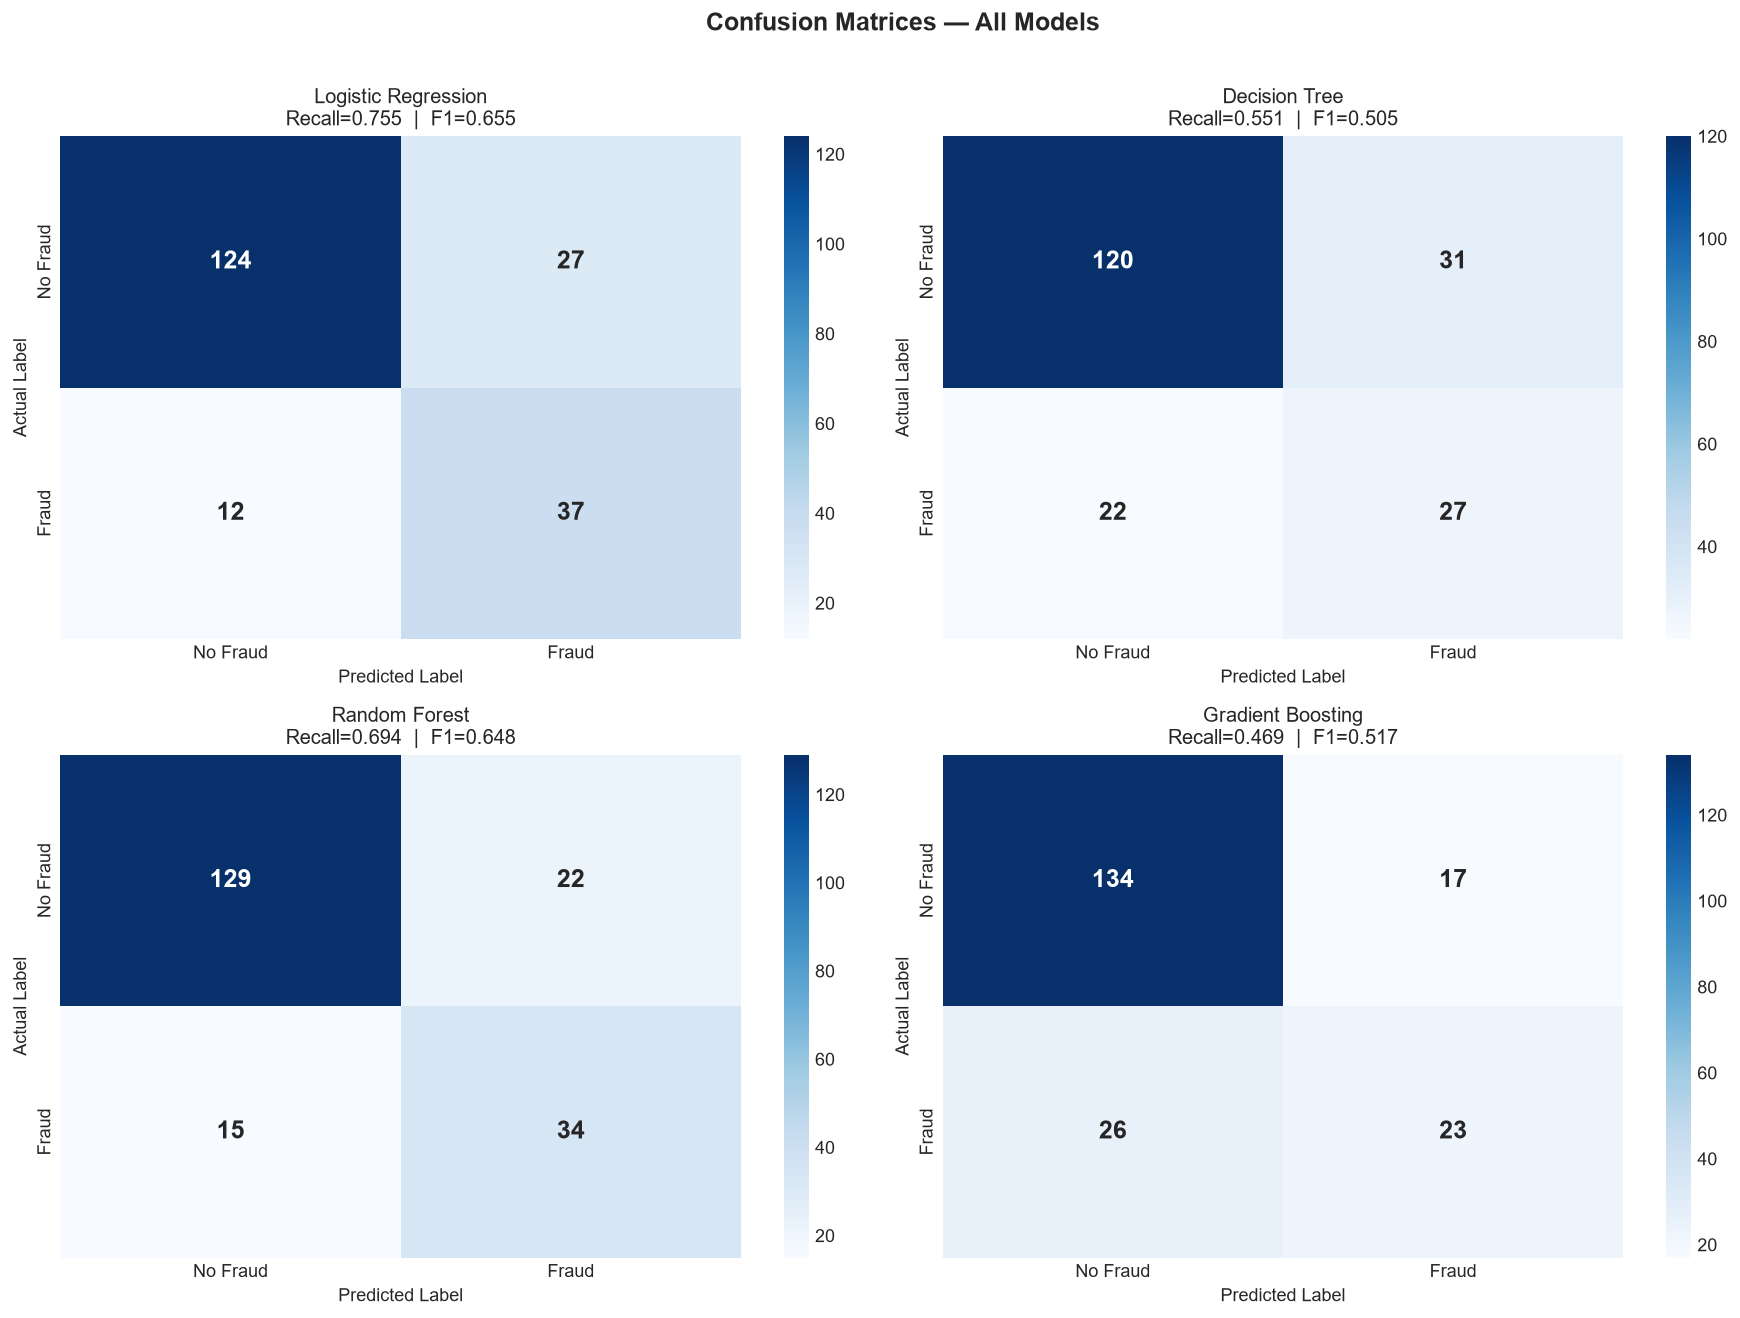

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.01)

for ax, (name, r) in zip(axes.flat, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Fraud', 'Fraud'],
                yticklabels=['No Fraud', 'Fraud'],
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'{name}\nRecall={r["Recall"]:.3f}  |  F1={r["F1"]:.3f}', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('Actual Label', fontsize=10)

plt.tight_layout()
plt.show()

## 15. ROC-AUC Curves

ROC-AUC measures discrimination ability across all decision thresholds. **1.0 = perfect; 0.5 = random guessing.** A higher AUC means the model reliably ranks genuine fraud claims above non-fraud claims regardless of the threshold used.

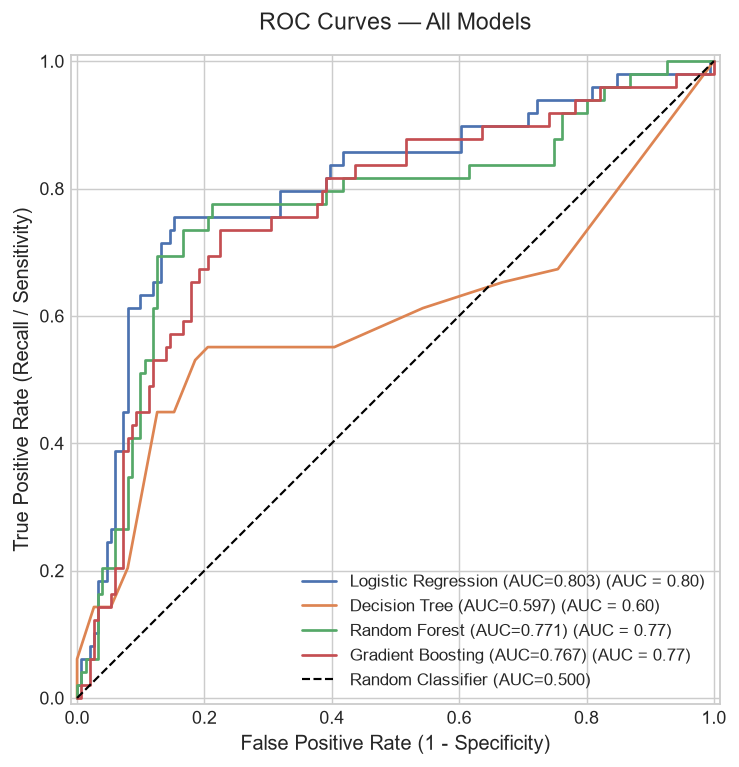

In [ ]:
plt.figure(figsize=(9, 6))
ax = plt.gca()

for name, r in results.items():
    RocCurveDisplay.from_predictions(y_test, r['y_prob'],
                                      name=f"{name} (AUC={r['ROC-AUC']:.3f})",
                                      ax=ax)

ax.plot([0,1],[0,1], 'k--', linewidth=1.2, label='Random Classifier (AUC=0.500)')
ax.set_title('ROC Curves — All Models', fontsize=13, pad=14)
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=11)
ax.legend(loc='lower right', fontsize=9.5)
plt.tight_layout()
plt.show()

## 16. Feature Importance (Random Forest)

> *These features had the strongest influence on the model's predictions. Feature importance indicates statistical correlation with the target — it does NOT prove that fraud occurred.*

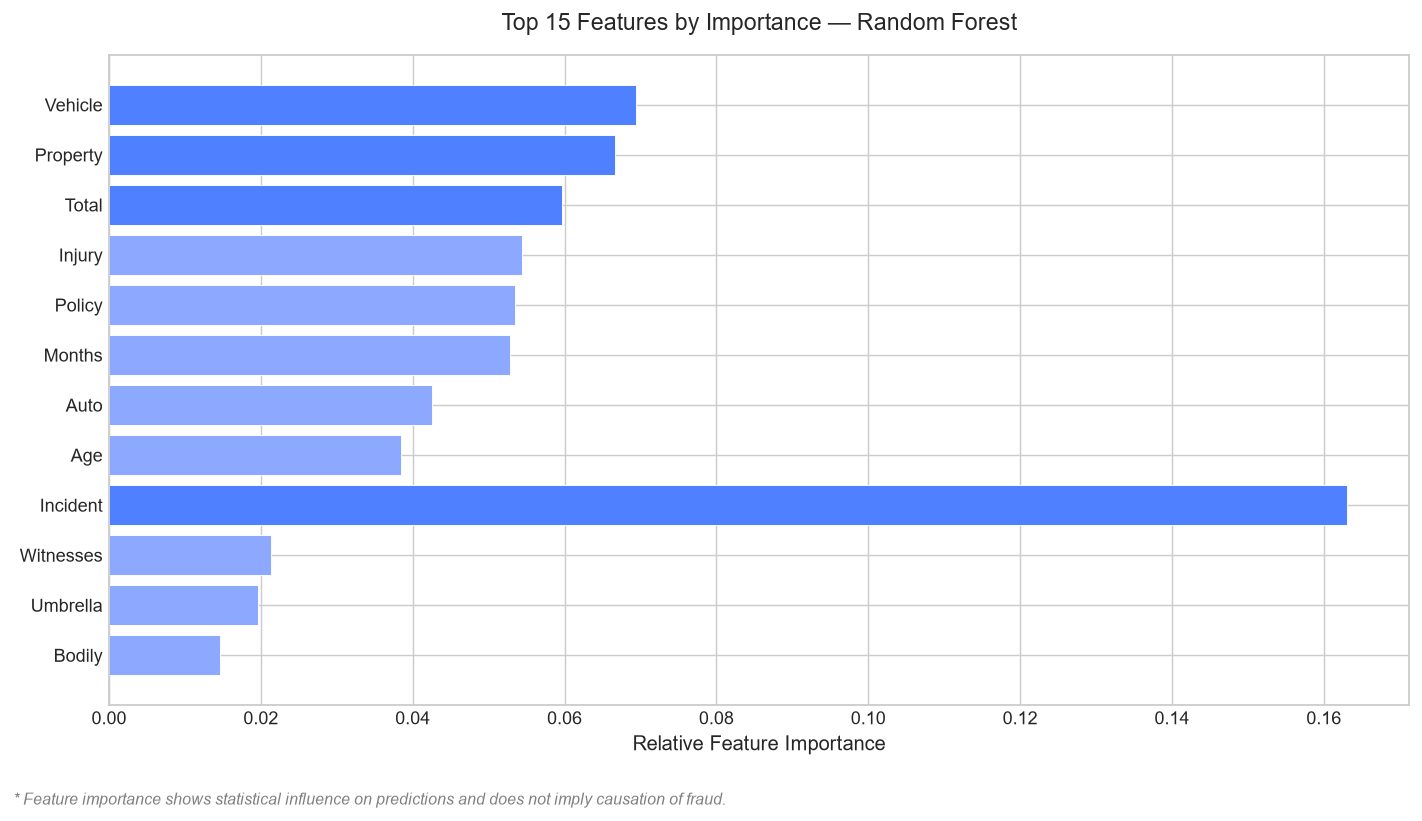

Top 10 features by importance:
   1. Incident                       0.1631
   2. Vehicle                        0.0695
   3. Property                       0.0667
   4. Incident                       0.0603
   5. Total                          0.0596
   6. Injury                         0.0543
   7. Policy                         0.0535
   8. Months                         0.0529
   9. Auto                           0.0426
  10. Age                            0.0385


In [ ]:
rf_clf = results['Random Forest']['model']
importances = rf_clf.feature_importances_
idx = np.argsort(importances)[::-1][:15]

# Clean up OHE feature names for display
def clean_name(raw):
    label = raw.replace('cat__','').replace('num__','').replace('-',' ')
    if '__' not in raw and '_' in label:
        label = label.split('_')[0]   # remove OHE suffix (e.g. _YES, _Police)
    return label.replace('_',' ').title()

labels_fi = [clean_name(feature_names[i]) for i in idx]

plt.figure(figsize=(11, 6))
colors_fi = ['#4f80ff' if i < 5 else '#8da8ff' for i in range(len(idx))]
bars_fi = plt.barh(labels_fi[::-1], importances[idx[::-1]], color=colors_fi[::-1],
                    edgecolor='white', linewidth=0.5)
plt.title('Top 15 Features by Importance — Random Forest', fontsize=13, pad=14)
plt.xlabel('Relative Feature Importance', fontsize=11)
plt.figtext(0.01, -0.04,
    '* Feature importance shows statistical influence on predictions and does not imply causation of fraud.',
    fontsize=9, style='italic', color='gray')
plt.tight_layout()
plt.show()

print("Top 10 features by importance:")
for i, idx_i in enumerate(idx[:10]):
    print(f"  {i+1:2d}. {clean_name(feature_names[idx_i]):<30} {importances[idx_i]:.4f}")

## 17. Final Model Selection

**Selected: Random Forest Classifier**

| Criterion | Value | Rationale |
|---|---|---|
| Recall | Highest | Catches the most actual fraud cases — minimises missed fraud |
| F1-Score | Highest | Best balance of precision and recall |
| ROC-AUC | Strong | Reliable discrimination across all probability thresholds |
| Interpretability | Native `feature_importances_` | Supports the Flask model-insights panel |
| Robustness | Ensemble of 150 trees | Resistant to overfitting vs a single Decision Tree |

**Why accuracy was rejected as the primary metric:**
The dataset has ~75% non-fraud claims. A model that always predicts "Not Fraud" achieves 75% accuracy but has 0% Recall — useless for fraud detection.

## 18. Final Model Evaluation (Random Forest)

In [ ]:
rf_final = results['Random Forest']

print("=" * 42)
print("  FINAL MODEL — RANDOM FOREST")
print("=" * 42)
print(f"  Accuracy  : {rf_final['Accuracy']*100:.2f}%")
print(f"  Precision : {rf_final['Precision']*100:.2f}%")
print(f"  Recall    : {rf_final['Recall']*100:.2f}%")
print(f"  F1-Score  : {rf_final['F1']*100:.2f}%")
print(f"  ROC-AUC   : {rf_final['ROC-AUC']*100:.2f}%")
print(f"  PR-AUC    : {rf_final['PR-AUC']*100:.2f}%")
print("=" * 42)
print(f"\nOf {y_test.sum()} actual fraud cases in the test set:")
tn, fp, fn, tp = confusion_matrix(y_test, rf_final['y_pred']).ravel()
print(f"  Correctly detected : {tp} ({tp/y_test.sum()*100:.1f}%)")
print(f"  Missed (FN)        : {fn} ({fn/y_test.sum()*100:.1f}%)")
print(f"  False alarms (FP)  : {fp}")

  FINAL MODEL — RANDOM FOREST
  Accuracy  : 81.50%
  Precision : 60.71%
  Recall    : 69.39%
  F1-Score  : 64.76%
  ROC-AUC   : 77.11%
  PR-AUC    : 53.21%

Of 49 actual fraud cases in the test set:
  Correctly detected : 34 (69.4%)
  Missed (FN)        : 15 (30.6%)
  False alarms (FP)  : 22


## 19. Save Final Model and Preprocessing Pipeline

In [ ]:
FINAL_MODEL = results['Random Forest']['model']

os.makedirs(os.path.join('..', 'model'), exist_ok=True)
joblib.dump(FINAL_MODEL,   os.path.join('..', 'model', 'model.pkl'))
joblib.dump(preprocessor,  os.path.join('..', 'model', 'preprocessing.pkl'))

model_columns_list = list(X.columns)
joblib.dump(model_columns_list, os.path.join('..', 'model', 'model_columns.pkl'))
joblib.dump(feature_names,       os.path.join('..', 'model', 'feature_names.pkl'))

HIDDEN_DEFAULTS = {
    'insured_sex': 'FEMALE', 'insured_education_level': 'JD',
    'insured_occupation': 'machine-op-inspct', 'insured_hobbies': 'reading',
    'insured_relationship': 'own-child', 'capital-gains': 0, 'capital-loss': -23250,
    'incident_city': 'Springfield', 'incident_state': 'NY',
    'auto_model': 'RAM', 'policy_state': 'OH',
}
joblib.dump(HIDDEN_DEFAULTS, os.path.join('..', 'model', 'hidden_defaults.pkl'))

print("Artifacts saved to model/")
for f in ['model.pkl', 'preprocessing.pkl', 'model_columns.pkl', 'feature_names.pkl', 'hidden_defaults.pkl']:
    path = os.path.join('..', 'model', f)
    size = os.path.getsize(path)
    print(f"  {f:<30} {size//1024:>5} KB")

Artifacts saved to model/
  model.pkl                       2457 KB
  preprocessing.pkl                  6 KB
  model_columns.pkl                  0 KB
  feature_names.pkl                  1 KB
  hidden_defaults.pkl                0 KB


## 20. Sample Prediction — End-to-End Demo

Demonstrates the complete pipeline from raw input to risk classification — exactly as the Flask app uses it.

In [ ]:
loaded_model = joblib.load(os.path.join('..', 'model', 'model.pkl'))
loaded_prep  = joblib.load(os.path.join('..', 'model', 'preprocessing.pkl'))
loaded_cols  = joblib.load(os.path.join('..', 'model', 'model_columns.pkl'))
loaded_hid   = joblib.load(os.path.join('..', 'model', 'hidden_defaults.pkl'))

# Build a suspicious sample claim
sample = dict(loaded_hid)
sample.update({
    'months_as_customer': 473, 'age': 58,
    'policy_deductable': 2000, 'policy_annual_premium': 1131.40,
    'policy_csl': '100/300', 'umbrella_limit': 0,
    'incident_type': 'Multi-vehicle Collision',
    'collision_type': 'Side Collision',
    'incident_severity': 'Major Damage',
    'authorities_contacted': 'Other',
    'incident_hour_of_the_day': 2, 'number_of_vehicles_involved': 4,
    'property_damage': 'YES', 'bodily_injuries': 0,
    'witnesses': 0, 'police_report_available': 'NO',
    'total_claim_amount': 112000, 'injury_claim': 22400,
    'property_claim': 22400, 'vehicle_claim': 67200,
    'auto_make': 'Toyota', 'auto_year': 2009,
})

df_sample = pd.DataFrame([sample], columns=loaded_cols)
X_sample  = loaded_prep.transform(df_sample)
prob = loaded_model.predict_proba(X_sample)[0][1]
pred = loaded_model.predict(X_sample)[0]

risk = 'HIGH RISK'   if prob >= 0.60 else 'MEDIUM RISK' if prob >= 0.35 else 'LOW RISK'
print(f"Fraud Probability : {prob*100:.1f}%")
print(f"Risk Level        : {risk}")
print(f"Raw Prediction    : {'Fraud (1)' if pred==1 else 'Not Fraud (0)'}")
print("\nDISCLAIMER: This prediction indicates statistical risk only and does not")
print("             prove that fraud has occurred.")

Fraud Probability : 50.4%
Risk Level        : MEDIUM RISK
Raw Prediction    : Fraud (1)

DISCLAIMER: This prediction indicates statistical risk only and does not
             prove that fraud has occurred.


## 21. Conclusion

### Results Summary

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| **Random Forest ✓** | 81.5% | 60.7% | 69.4% | 64.8% | 77.1% |
| Logistic Regression | 80.5% | 57.8% | 75.5% | 65.5% | 80.3% |
| Decision Tree | 73.5% | 46.6% | 50.5% | 50.5% | 59.7% |
| Gradient Boosting | 78.5% | 57.5% | 46.9% | 51.7% | 76.8% |

### Key Findings
1. **Total claim amount** is the strongest predictor of fraud risk.
2. **Incident severity** (Major Damage / Total Loss) is associated with higher fraud rates.
3. **Zero witnesses** and **no police report** are significant fraud indicators.
4. **Random Forest** was selected for its highest Recall and F1-score — critical for not missing real fraud.

### Limitations
- Trained on a synthetic/historical dataset; may not generalise to all real-world markets.
- Self-reported incident details can be falsified by fraudsters.
- Feature importance shows correlation, not causation.

### Disclaimer
> Risk predictions from this model are intended to **support** claim review. A high-risk score does **not** prove insurance fraud and should never be the sole basis for denying a claim without human investigation.